## Spectral Analysis in MA

In [1]:
state='MA'

## Loading libraries and data
### Load the required libraries

In [2]:
import pandas as pd
import numpy as np
import sklearn as sk

In [3]:
import matplotlib

In [4]:
import warnings  # Suppress Warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2 

_figsize=(10,7)

### Read or compute Statistics File

In [5]:
presentWD = !pwd
ns = presentWD[0].split('/')[2]
parquet_root=f'/home/{ns}/public/Data/weather'
print('parquet_root=',parquet_root)

parquet_root= /home/grader-cse255-01/public/Data/weather


In [6]:
ms=['TMAX', 'SNOW', 'SNWD', 'TMIN', 'PRCP', 'TOBS']
# ms=['TMAX', 'TMIN', 'TOBS']
cms='or\n'.join(['Measurement="%s" '%(m) for m in ms])


In [11]:
### read or compute statistics information for state.

import os.path
from pickle import dump,load

pkl_filename=parquet_root+'/weather-statistics/'+state+'-'+','.join(ms)+'.pkl'
!ls $pkl_filename

/home/grader-cse255-01/public/Data/weather/weather-statistics/MA-TMAX,SNOW,SNWD,TMIN,PRCP,TOBS.pkl


In [8]:
if os.path.isfile(pkl_filename):   
    print('precomputed statistics file exists')
    with open(pkl_filename,'br') as pkl_file:
        stat=load(pkl_file)
else:
    print('error: no precomputed statistics file')
STAT=stat
stat.keys()

precomputed statistics file exists


dict_keys(['TMAX', 'SNOW', 'SNWD', 'TMIN', 'PRCP', 'TOBS'])

## Plot mean and top eigenvectors

Construct approximations of a time series using the mean and the $k$ top eigen-vectors
First, we plot the mean and the top $k$ eigenvectors

In [9]:
STAT.keys()

dict_keys(['TMAX', 'SNOW', 'SNWD', 'TMIN', 'PRCP', 'TOBS'])

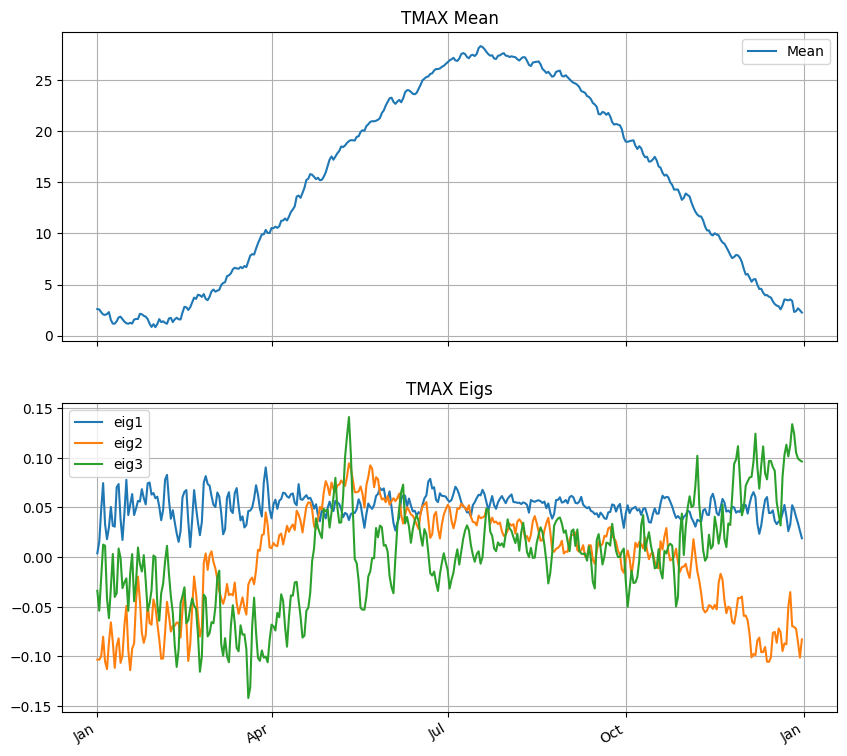

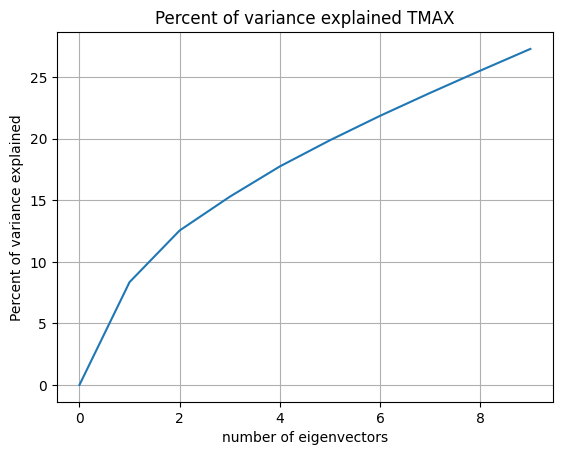

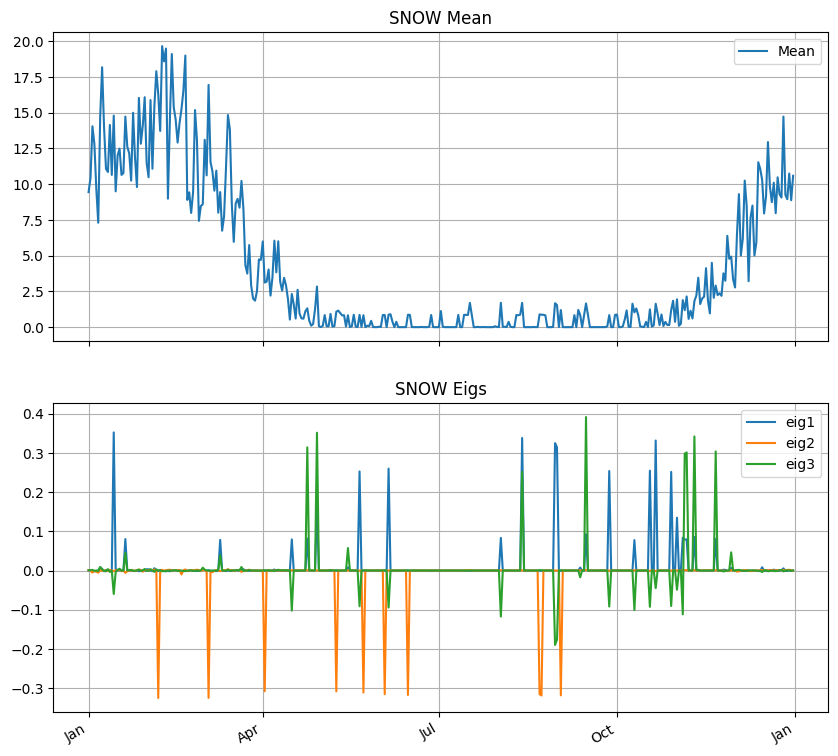

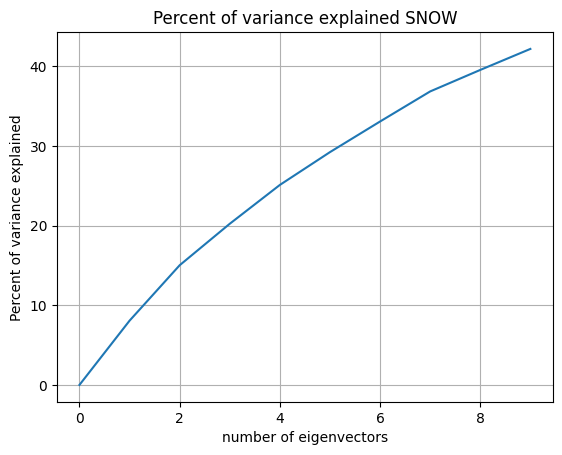

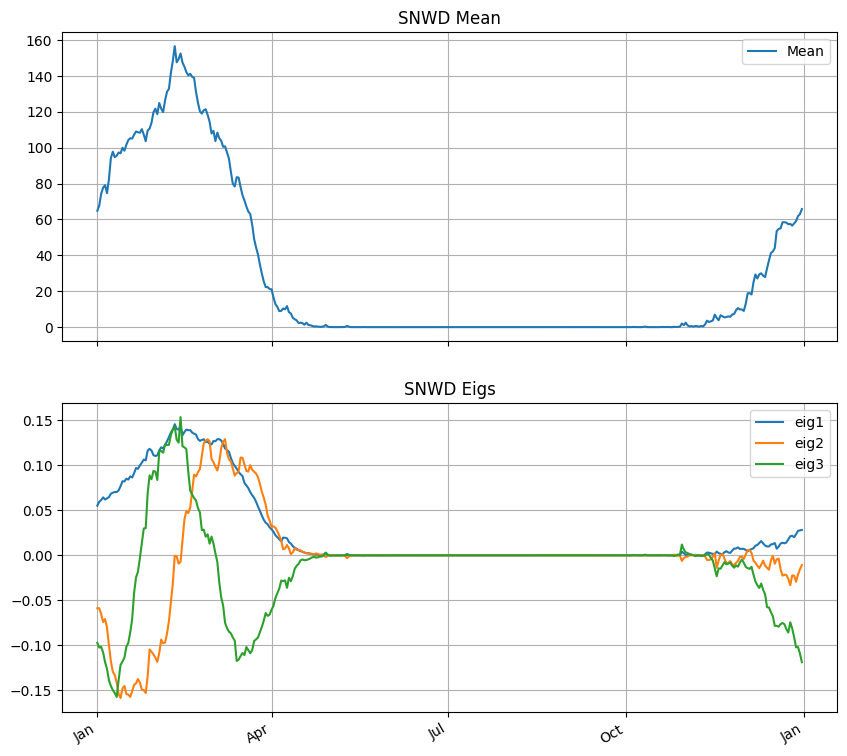

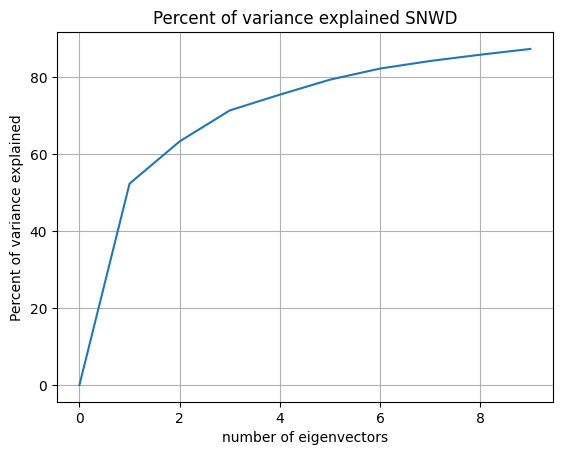

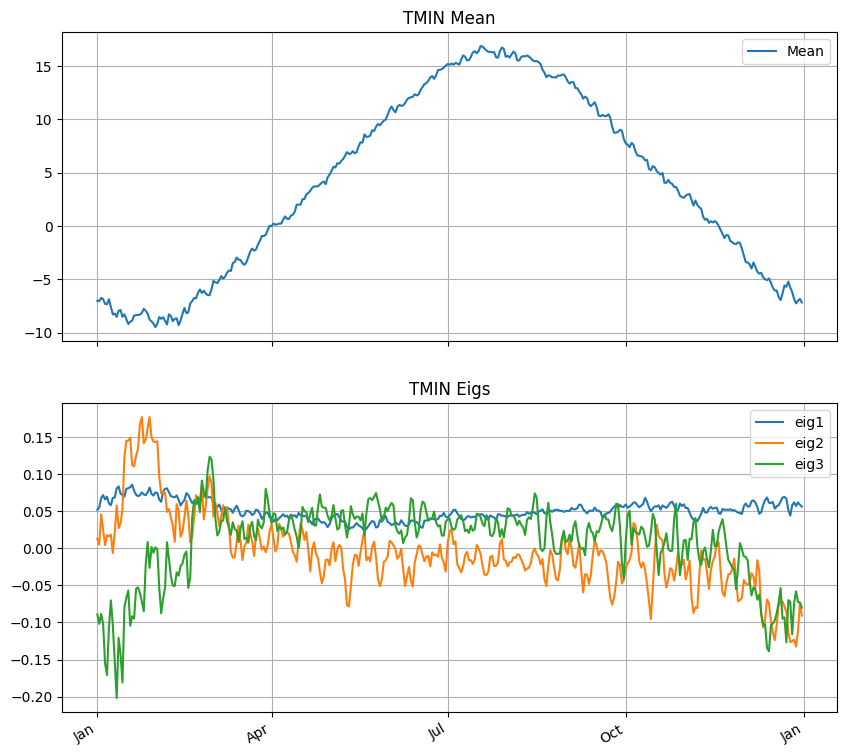

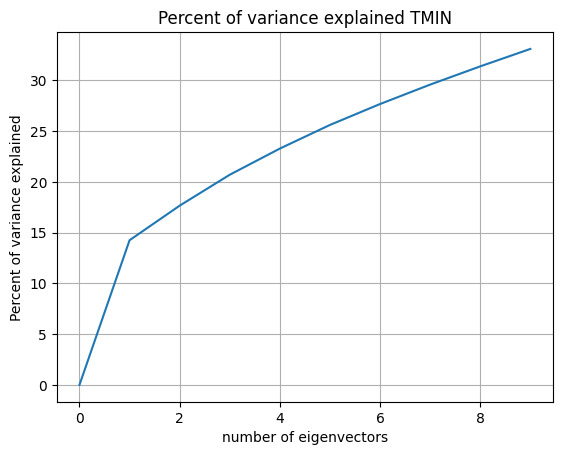

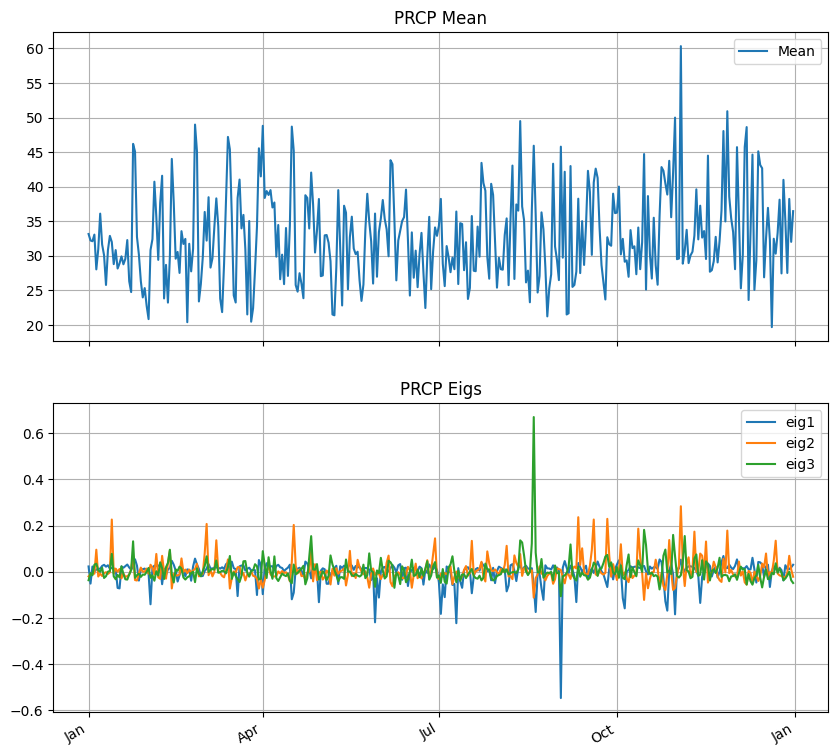

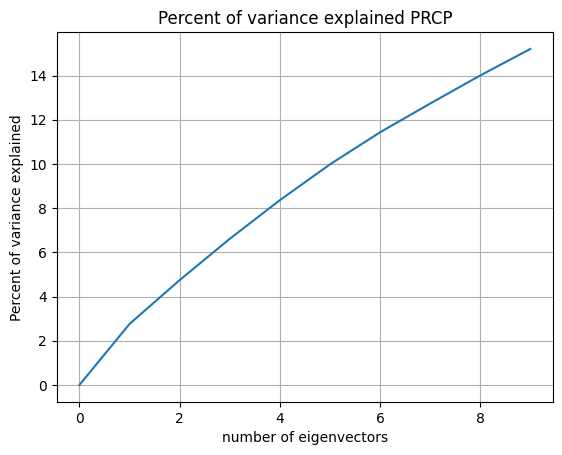

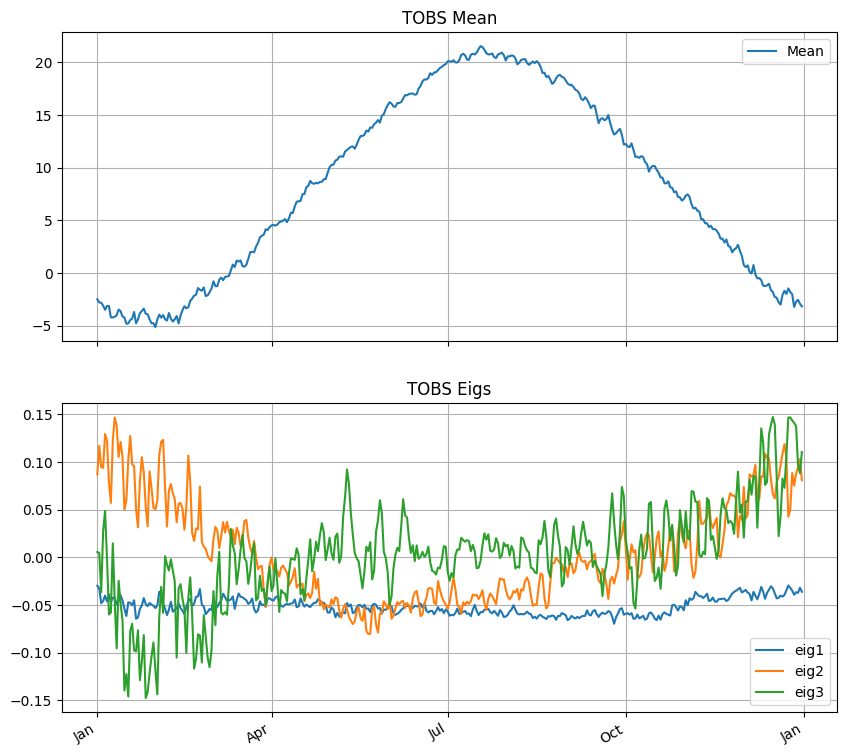

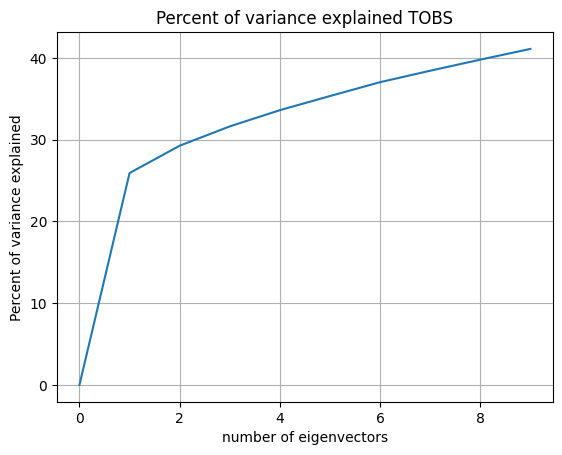

In [10]:
import pylab as plt
from lib.YearPlotter import YearPlotter

for m in STAT.keys():
    fig,axes=plt.subplots(2,1, sharex='col', sharey='row',figsize=(10,10));
    k=3
    EigVec=np.array(STAT[m]['eigvec'][:,:k])
    Mean=STAT[m]['Mean']
    YearPlotter().plot(Mean,fig,axes[0],label='Mean',title=m+' Mean')
    YearPlotter().plot(EigVec,fig,axes[1],title=m+' Eigs',labels=['eig'+str(i+1) for i in range(k)])
    fig,ax=plt.subplots(1,1);
    eigvals=STAT[m]['eigval']; eigvals/=sum(eigvals); cumvar=np.cumsum(eigvals); cumvar=100*np.insert(cumvar,0,0)
    ax.plot(cumvar[:10]); 
    ax.grid(); 
    ax.set_ylabel('Percent of variance explained')
    ax.set_xlabel('number of eigenvectors')
    ax.set_title('Percent of variance explained '+m);